In [1]:
import numpy as np
import yfinance as fy
import QuantLib as ql
from typing import Optional, Union
import pandas as pd
import matplotlib.pyplot as plt
import mocaxpy
import multiprocess
import time
import seaborn as sb

from inception.instruments.constant_parameters import NOTES_PARAMETERS
from inception.utils import timer
from inception.quantlib_python import date_to_date
from inception.instruments import ReferenceMultiIndexReturnSimulator, MultiAssetAutoCallableNote
from inception.utils import timer
from tqdm import tqdm

In [2]:
def autocallable_note_pricer(spot_price: list, evaluate_date: Union[str, pd.Timestamp]):
    """
    The Autocallable Notes pricer function wrapper, (adapts the original function signature to the signature expected by MoCaX)
    :param x: [stock A price, stock B price, stock C price, days after the start date]
    :param additional_data: extra parameters required by MoCaX
    """
    import numpy as np
    import pandas as pd
    from inception.instruments.constant_parameters import NOTES_PARAMETERS
    from inception.instruments import ReferenceMultiIndexReturnSimulator, MultiAssetAutoCallableNote
    
    start_date = '2024-02-14'
    corr_matrix = np.array(
        [[1.        , 0.96432854, 0.80799003],
        [0.96432854, 1.        , 0.8267037 ],
        [0.80799003, 0.8267037 , 1.        ]]
    )
    issued_price = [382.82, 494.08, 142.86]
    index_vol = [0.16, 0.16, 0.16]
    risk_free_rate = 0.05
    path_num = 100_000
    d_s = 0.02
    parameters = NOTES_PARAMETERS['Multi Assets One Year']
    simulator = ReferenceMultiIndexReturnSimulator(issued_price, spot_price, risk_free_rate, index_vol, corr_matrix, d_s)
    notes = MultiAssetAutoCallableNote(evaluate_date,
                                       ['A', 'B', 'C'],
                                       simulator, 
                                       parameters['valuation dates'],
                                       parameters['coupon dates'],
                                       parameters['call dates'],
                                       coupon_barrier=parameters['coupon barrier'],
                                       call_barrier=parameters['call barrier'],
                                       principal_barrier=parameters['principal barrier'],
                                       coupon_amount=parameters['coupon amount'],
                                       free_rate=risk_free_rate,
                                       n_paths=path_num)

    
    return notes.value

In [9]:
autocallable_note_pricer([382.82, 494.08, 142.86], '2024-04-15')

102.04206522075667

## Validation

In [10]:
date = '2024-05-15'
file = f'./one_year_chebyshev_database/{date}.mcx'
notes_mc = mocaxpy.Mocax.deserialize(file)

In [25]:
notes_mc.get_domain().export_as_list()

[[76.56400000000001, 421.10200000000003],
 [98.816, 543.488],
 [28.572000000000003, 157.14600000000002]]

In [27]:
a, b = [1, 3]

In [28]:
a

1

In [26]:

notes_mc.eval([382.82, 494.08, 142.86])

100.41799098503084

In [12]:
func = lambda x: np.random.uniform(x * 0.2, x * 1.1)
m_id = notes_mc.get_derivative_id([0, 0, 0])
issued_price = [382.82, 494.08, 142.86]
# Function domain for stock A, B and C price, Time to Maturity
random_x = [[func(x) for x in issued_price] for _ in range(100)]

t1 = time.time()
value_m = [notes_mc.eval(x, m_id) for x in random_x]

t2 = time.time()
value_p = [autocallable_note_pricer(x, date) for x in random_x]
t3 = time.time()

In [13]:
t3 - t2

50.43281078338623

Maximum error: 3.49269
Mean error: 0.70737


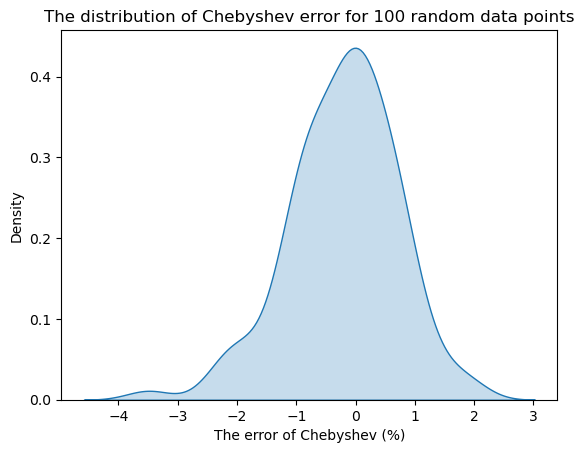

In [14]:
error_2 = (np.array(value_p) - np.array(value_m)) / np.array(value_p) * 100
sb.kdeplot(error_2,fill=True)
plt.title('The distribution of Chebyshev error for 100 random data points')
plt.xlabel('The error of Chebyshev (%)')

# -- Empirical error
error_sup = max(abs(error_2))
error_mean = abs(error_2).mean()

print(f"Maximum error: {error_sup:.5f}")
print(f"Mean error: {error_mean:.5f}")

In [9]:
path_num = 100_000

stock_price = [382.82, 494.08, 142.86]
p_range = np.arange(0.6, 1.1, 0.01)
corr = np.array(
    [[1., 0.96432854, 0.80799003],
     [0.96432854, 1., 0.8267037],
     [0.80799003, 0.8267037, 1.]]
)
issued_price = [382.82, 494.08, 142.86]
index_vol = [0.16, 0.16, 0.16]
risk_free_rate = 0.05
parameters = NOTES_PARAMETERS['Multi Assets One Year']

delta_list = []
gamma_list = []
value_list = []

for p in tqdm(p_range):
    stock_price[0] = issued_price[0] * p
    simulator = ReferenceMultiIndexReturnSimulator(issued_price, stock_price, risk_free_rate, index_vol, corr, seed=None)
    notes = MultiAssetAutoCallableNote(date,
                                   ['A', 'B', 'C'],
                                   simulator,
                                   parameters['valuation dates'],
                                   parameters['coupon dates'],
                                   parameters['call dates'],
                                   coupon_barrier=parameters['coupon barrier'],
                                   call_barrier=parameters['call barrier'],
                                   principal_barrier=parameters['principal barrier'],
                                   coupon_amount=parameters['coupon amount'],
                                   free_rate=risk_free_rate,
                                   n_paths=path_num)

    value_list.append(notes.value)
    delta_list.append(notes.delta)
    gamma_list.append(notes.gamma)

100%|██████████████████████████████████████████████████████████████████████████████████| 51/51 [01:58<00:00,  2.32s/it]


In [14]:
m_id = notes_mc.get_derivative_id([0, 0, 0])
m_id_1 = notes_mc.get_derivative_id([1, 0, 0])
m_id_2 = notes_mc.get_derivative_id([2, 0, 0])

delta_list_v2 = []
gamma_list_v2 = []
value_list_v2 = []

for p in tqdm(p_range):
    stock_price[0] = issued_price[0] * round(p,2)
    value_list_v2.append(notes_mc.eval(stock_price, m_id))
    delta_list_v2.append(notes_mc.eval(stock_price, m_id_1))
    gamma_list_v2.append(notes_mc.eval(stock_price, m_id_2))

100%|████████████████████████████████████████████████████████████████████████████████| 51/51 [00:00<00:00, 6675.70it/s]


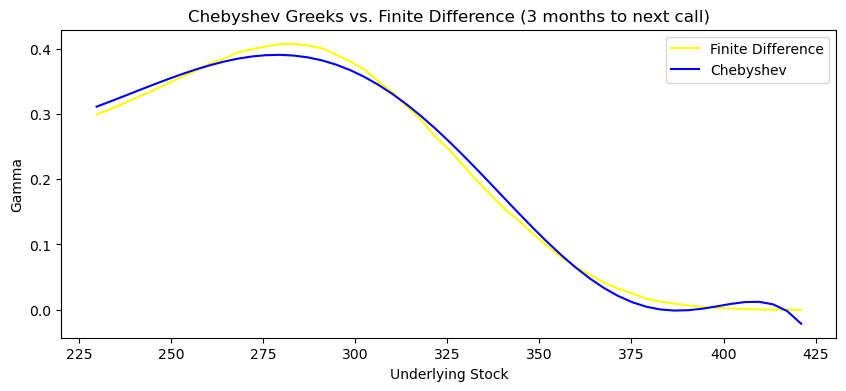

In [30]:
plt.figure(figsize=[10, 4])
plt.plot([issued_price[0] * p for p in p_range], [d['A'] for d in delta_list], color='yellow', label='Finite Difference')
plt.plot([issued_price[0] * p for p in p_range], [d for d in delta_list_v2], color='blue', label='Chebyshev')

plt.title('Chebyshev Greeks vs. Finite Difference (3 months to next call)');
plt.ylabel('Gamma')
plt.xlabel('Underlying Stock')
plt.legend()